### Random Forest por grupo

In [1]:
import json

import geopandas as gdp
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gdf = gdp.read_file("../../../data/chla_indices_v1.geojson")
gdf.head(2)

,fecha,chla,grupo_nombre,estado_trofico,ndci_median,ndci_mean,ndci_iqr,ndci_std,indice_tres_bandas_median,indice_tres_bandas_mean,...,B03_mean,B04_median,B04_mean,B05_median,B05_mean,B06_median,B06_mean,B07_median,B07_mean,geometry
0,2017-01-02,6.8,LDS,O,-0.046154,-0.045572,0.002933,0.002157,0.000026,0.000025,...,0.081760,0.0713,0.071264,0.0650,0.065052,0.0417,0.041656,0.0410,0.04102,POINT (678380.002 6147956.963)
1,2017-01-02,3.2,LDS,O,-0.048656,-0.049677,0.002722,0.003910,0.000029,0.000029,...,0.081296,0.0716,0.071632,0.0646,0.064852,0.0425,0.042280,0.0423,0.04216,POINT (679045.962 6144090.994)


In [3]:
gdf = gdf.drop(columns=["fecha", "geometry", "chla"])
df = pd.DataFrame(gdf)
df = df.dropna()  # ~50 filas sin features calculados (muy pocos pixeles claros/agua)
df.shape

(1575, 30)

In [4]:
estados_encoding = {
    "U": 0,
    "O": 1,
    "M": 2,
    "E": 3
}
inv_encoding = {v: k for k, v in estados_encoding.items()}
df["estado_trofico"] = df["estado_trofico"].map(estados_encoding)

df.groupby("grupo_nombre")["estado_trofico"].value_counts().unstack().rename(columns=inv_encoding)

estado_trofico,U,O,M,E
grupo_nombre,,,,
LDS,109.0,377.0,124.0,13.0
RDP-MONTES,41.0,63.0,13.0,NaN
RN-UPM1,12.0,37.0,39.0,4.0
RN-UPM2,329.0,310.0,84.0,20.0


#### Hiperparametros por grupo (RandomForest)
Barrido sobre `n_estimators` x `max_depth` x `min_samples_leaf` x `max_features` x `class_weight`
hecho por `tools/sweep_rf_por_grupo.py`, quedandonos con el que maximiza accuracy en el split de
validacion de ese grupo. Los `BEST_PARAMS` se cargan directo del JSON que ese script genera
(`tools/sweep_rf_por_grupo_resultados.json`) en vez de estar hardcodeados -- correr el script antes
si el JSON no existe todavia. Verificado reproducible (RandomForest con `random_state` fijo es
determinista).

In [5]:
with open("../../../tools/sweep_rf_por_grupo_resultados.json") as f:
    sweep_resultados = json.load(f)

BEST_PARAMS = {grupo: info["params"] for grupo, info in sweep_resultados.items()}
BEST_PARAMS

{'LDS': {'n_estimators': 256,
  'max_depth': 10,
  'min_samples_leaf': 1,
  'max_features': 'log2',
  'class_weight': 'balanced_subsample'},
 'RDP-MONTES': {'n_estimators': 256,
  'max_depth': None,
  'min_samples_leaf': 2,
  'max_features': 'sqrt',
  'class_weight': 'balanced_subsample'},
 'RN-UPM1': {'n_estimators': 64,
  'max_depth': None,
  'min_samples_leaf': 2,
  'max_features': None,
  'class_weight': None},
 'RN-UPM2': {'n_estimators': 256,
  'max_depth': 7,
  'min_samples_leaf': 4,
  'max_features': 'sqrt',
  'class_weight': 'balanced_subsample'}}

In [6]:
def plot_cm(y_true, y_pred, labels, target_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
    plt.title(title)
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    plt.show()

In [7]:
def entrenar_grupo(df, grupo, params, plot=True):
    sub = df[df["grupo_nombre"] == grupo]
    X = sub.drop(columns=["grupo_nombre", "estado_trofico"])
    y = sub["estado_trofico"]

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

    rf = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_val_pred = rf.predict(X_val)

    labels = sorted(y.unique())
    target_names = [inv_encoding[c] for c in labels]

    print(f"=== {grupo} (n={len(sub)}, train={len(X_train)}, val={len(X_val)}) ===")
    print(f"params: {params}")
    print(classification_report(y_val, y_val_pred, labels=labels, target_names=target_names, zero_division=0))

    if plot:
        plot_cm(y_val, y_val_pred, labels, target_names, title=f"{grupo} - Validacion (v3 RF)")

    return {
        "grupo": grupo,
        "n_total": len(sub),
        "n_train": len(X_train),
        "n_val": len(X_val),
        "acc_train": accuracy_score(y_train, y_train_pred),
        "acc_val": accuracy_score(y_val, y_val_pred),
    }

=== LDS (n=623, train=529, val=94) ===
params: {'n_estimators': 256, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}
              precision    recall  f1-score   support

           U       0.33      0.12      0.18        16
           O       0.71      0.93      0.80        57
           M       0.75      0.47      0.58        19
           E       1.00      0.50      0.67         2

    accuracy                           0.69        94
   macro avg       0.70      0.51      0.56        94
weighted avg       0.66      0.69      0.65        94



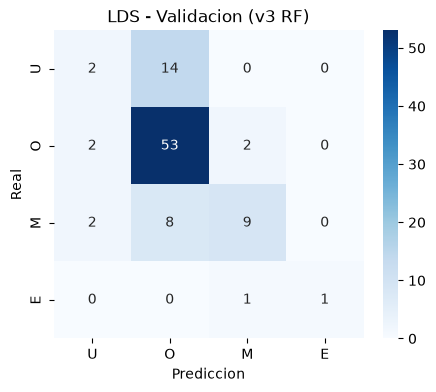

=== RDP-MONTES (n=117, train=99, val=18) ===
params: {'n_estimators': 256, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}
              precision    recall  f1-score   support

           U       0.86      1.00      0.92         6
           O       0.91      1.00      0.95        10
           M       0.00      0.00      0.00         2

    accuracy                           0.89        18
   macro avg       0.59      0.67      0.63        18
weighted avg       0.79      0.89      0.84        18



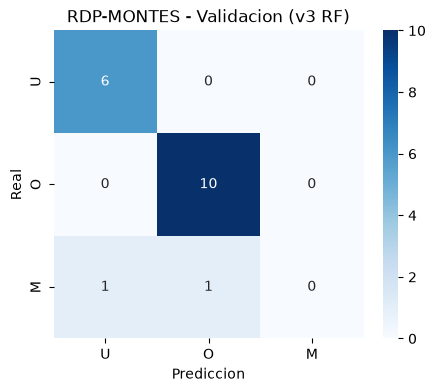

=== RN-UPM1 (n=92, train=78, val=14) ===
params: {'n_estimators': 64, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': None, 'class_weight': None}
              precision    recall  f1-score   support

           U       0.00      0.00      0.00         2
           O       0.71      0.83      0.77         6
           M       0.86      1.00      0.92         6
           E       0.00      0.00      0.00         0

    accuracy                           0.79        14
   macro avg       0.39      0.46      0.42        14
weighted avg       0.67      0.79      0.73        14



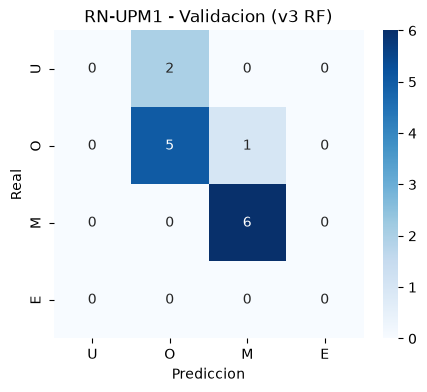

=== RN-UPM2 (n=743, train=631, val=112) ===
params: {'n_estimators': 256, 'max_depth': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}
              precision    recall  f1-score   support

           U       0.61      0.63      0.62        49
           O       0.63      0.57      0.60        47
           M       0.59      0.77      0.67        13
           E       0.00      0.00      0.00         3

    accuracy                           0.61       112
   macro avg       0.46      0.49      0.47       112
weighted avg       0.60      0.61      0.60       112



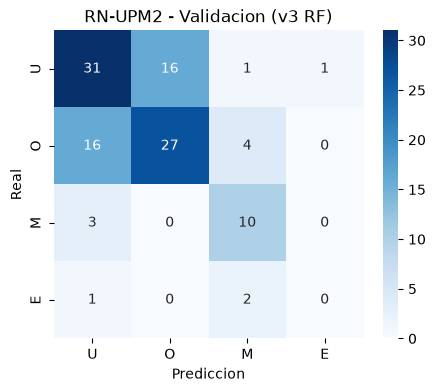

In [8]:
resultados = [entrenar_grupo(df, grupo, BEST_PARAMS[grupo]) for grupo in df["grupo_nombre"].unique()]

#### Resumen comparativo

In [9]:
resumen = pd.DataFrame(resultados).set_index("grupo")
resumen

,n_total,n_train,n_val,acc_train,acc_val
grupo,,,,,
LDS,623,529,94,0.971645,0.691489
RDP-MONTES,117,99,18,1.000000,0.888889
RN-UPM1,92,78,14,0.974359,0.785714
RN-UPM2,743,631,112,0.786054,0.607143


#### v1 (arbol, max_depth=5) vs v2 (arbol tuneado) vs v3 (random forest tuneado) vs modelo pooled